In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import torch
import matplotlib.pyplot as plt
from IPython.display import HTML
from src.cnn_lstm_v2 import CNNLSTMV2
from src.XAI.gradcam import GradCAM
from src.XAI.insertion_deletion_auc import AUC_TEST
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_gradcam_over_rgb, plot_single_frame_gradcam, animate_saliency_over_rgb
from scripts.common.get_device import get_available_device

experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_1" / "baseline"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

model = CNNLSTMV2(
    hidden_channels=hyperparameters["hidden_channels"],
    reduced_channels=hyperparameters["reduced_channels"],
    classifier_hidden_size=hyperparameters["classifier_hidden_size"],
    dropout=hyperparameters["dropout"],
    cnn_cutoff=hyperparameters["cnn_cutoff"],
    cnn_unfreeze_from=hyperparameters["cnn_unfreeze_from"]
).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

dataset = RWF2000Dataset(
    DATASET_ROOT, 
    num_frames=hyperparameters["num_frames"], 
    input_mode=hyperparameters["input_mode"], 
    augment=False, 
    split="val", 
    return_rgb_frames=True
)

video_num = 300
video, label, rgb_frames = dataset[video_num]
video = video.unsqueeze(0).to(device)
# [1, 32, 3, 224, 224]

label = label.item()

Using cuda:0 with 23.35 GB free


In [3]:
gradcam=GradCAM(model, model.cnn[-1], normalisation_mode="per_video")
auc_test=AUC_TEST(model)

cams, logits = gradcam.generate_heatmap(video)
saliency_map = cams[0]

In [4]:
deletion_results = auc_test.deletion(video, saliency_map)
insertion_results = auc_test.insertion(video, saliency_map)
results = [deletion_results, insertion_results]
labels = ["deletion", "insertion"]

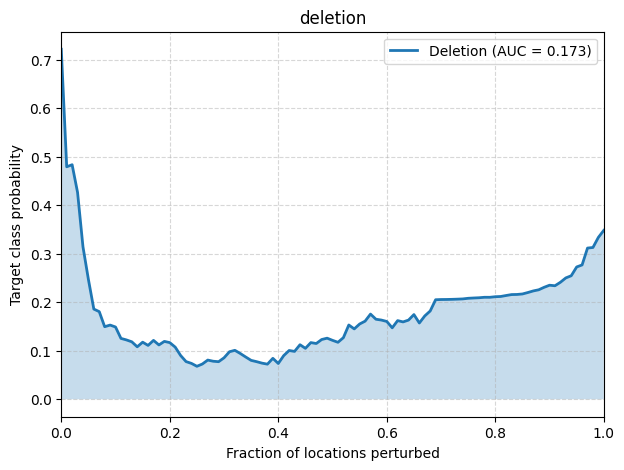

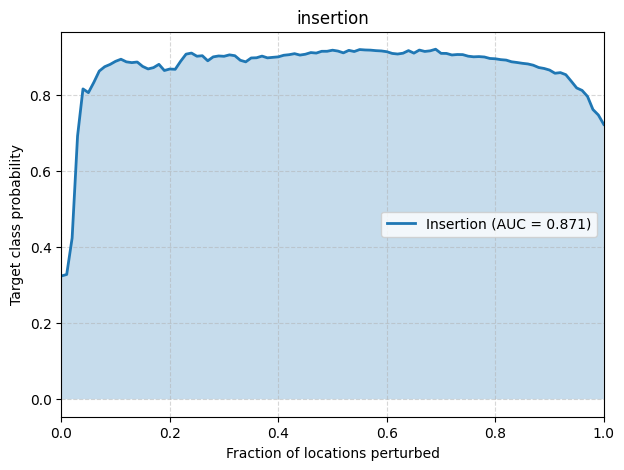

In [ ]:
for label, result in zip(labels, results):

    fig, ax = plt.subplots(figsize=(7,5))
    AUC_TEST.plot_auc_curve(result, ax=ax)
    ax.set_title(label)
    ax.legend()
    plt.show()